#### SHAP - GPU -version

This most likely requires your computer/laptop has an Nvidia GPU with CUDA -support. 

c:\Users\tuomas.valtanen\advda2025lecturenotes\AdvancedDataAnalytics2025\.venv\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


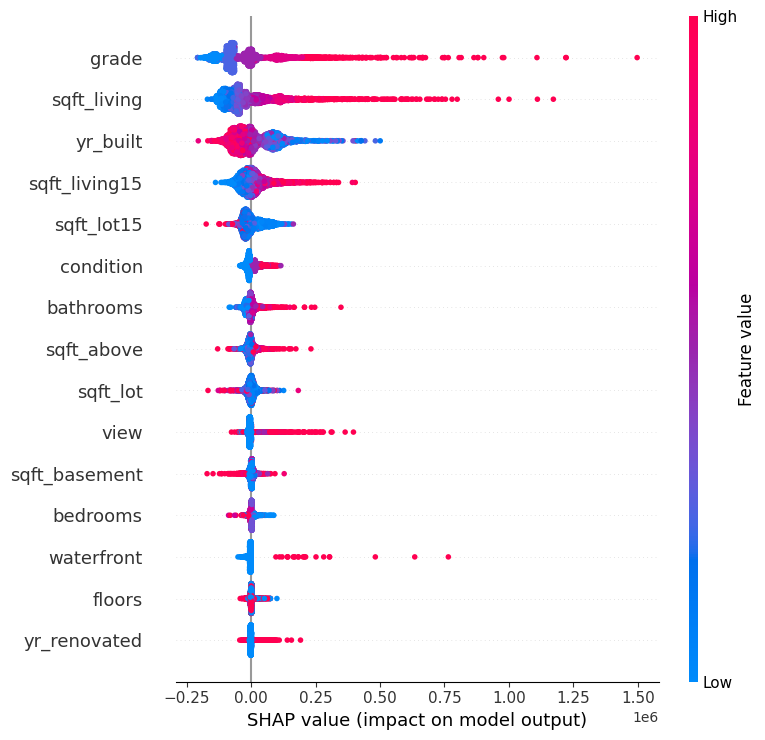

Feature Importances using SHAP:
          Feature    Importance
0        bedrooms   5451.408691
1       bathrooms  14433.912109
2     sqft_living  88786.218750
3        sqft_lot  11954.277344
4          floors   4420.721191
5      waterfront   5403.341797
6            view   9784.319336
7       condition  16345.273438
8           grade  94828.367188
9      sqft_above  12134.279297
10  sqft_basement   7220.844727
11       yr_built  61477.367188
12   yr_renovated   2979.745117
13  sqft_living15  37654.218750
14     sqft_lot15  29397.488281


In [1]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
df = pd.read_csv("../houses.csv")

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['id', 'date', 'zipcode', 'lat', 'long'], axis=1)

# Define features and target
X = df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15',
       'sqft_lot15']]

y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# use GPU-enabled XGBoost Regressor
model = xgb.XGBRegressor(tree_method='gpu_hist')
model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test)

# Feature importance using SHAP values
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.mean(np.abs(shap_values.values), axis=0)  # shap_values.values for the matrix
})

print("Feature Importances using SHAP:")
print(importance)
